# HW3: Bayesian Inference & Monte Carlo

## Problem 1
You are monitoring an X-ray binary with a space telescope. The source is intrinsically variable with the true flux drawn
visit-to-visit from a Gaussian population,
$$F_{\rm true} \sim \mathcal{N}(\mu, \sigma),$$
with mean $\mu$ and intrinsic scatter $\sigma$. 
Each visit $i$ then yields a *measured* photon count $F_i$ drawn from a Poisson process around that visit's true flux, with reported Poisson uncertainty $e_i = \sqrt{F_i}$ . 

**(a)** Generate $N = 80$ synthetic visits with $\mu_{\rm true} = 500$ counts and $\sigma_{\rm true} = 40$ counts (hint: `scipy.stats.norm`,
`scipy.stats.poisson`). Plot the measurements with error bars.

**(b)** Write down the likelihood $P(\{F_i, e_i\}\,|\,\mu,\sigma)$ and `log_likelihood(theta, F, e)`. Then find the maximum-likelihood estimate (MLE; $\hat\mu_{\rm MLE}, \hat\sigma_{\rm MLE}$) (hint: `scipy.optimize.minimize`). 
Plot the log-likelihood on a $(\mu,\sigma)$ grid and compare it against your MLE estimate and the true $\mu_{\rm true}$ and $\sigma_{\rm true}$. 

**(c)** A previous mission measured the same source's variability amplitude to be $\sigma = 35 \pm 6$ counts. 
Incorporate this as a Gaussian prior on $\sigma$.
Derive and implement the `log_posterior`, then find the maximum a posteriori (MAP) estimate.
Plot the log-posterior on a $(\mu,\sigma)$ grid and compare it against your MAP estimate and the true $\mu_{\rm true}$ and $\sigma_{\rm true}$. 
How does the log-posterior compare to the log-likelihood from (b)? 

**(d)** Repeat (b) and (c) using only the first $N=5$ visits instead of 80. Compare the MLE and MAP in the small-$N$ and large-$N$
cases. How about for $N=40$? How does the prior's influence change with $N$ and why? 

## Problem 2 
The abundance of galaxies as a function of stellar mass (the stellar mass function; SMF) is well often by a Schechter function. In terms of stellar mass $M$,
$$\frac{dN}{dM} \propto \left(\frac{M}{M^\star}\right)^{\alpha} \exp\!\left(-\frac{M}{M^\star}\right),
\qquad \alpha = -1.4,\ \ M^\star = M_\odot^{10.7},\ \ M \in [10^8,\,10^{12}]\ M_\odot$$

Let's try to sample from this distribution using rejection sampling

**(a)** Implement and plot the unnormalized target distribution $\tilde p(M) = M^{\alpha}\exp(-M/M^\star)$. 

*Hint: log-log plot*

**(b)** Find a proposal distribution, $q(M)$, and derive the bounding constant $C$ such that  $C q(M) \ge \tilde{p}(M)$ over $M \in [10^8,\,10^{12}]\ M_\odot$. 

*Hint 1: $\exp(-M/M^\star) \le 1$*

*Hint 2: A power-law can be sampled via inverse-CDF transform.*


**(c)** Implement rejection sampling and drawn 100,000 samples from  $\tilde{p}(M)$. 
Compare the the histogram of the samples to the SMF. What was the acceptance rate? 

**(d).** Using your samples, estimate the fraction of galaxies more massive than the characteristic mass
$M > M^\star$.

**(e)** Assuming all galaxies have $M\in[10^8, 10^{12}]M_\odot$, what fraction of the universe's total stellar mass do $M > M^*$ galaxies hold? 

## Problem 3
You are searching for a planet in radial-velocity (RV) data. 
The RV signal induced by a planet on a circular orbit is
$$v(t) = v_0 + K \sin\!\left(\frac{2\pi t}{P} + \phi\right),$$
with systemic velocity $v_0$, semi-amplitude $K$, period $P$, and phase $\phi$.

**(a)** Generate 17 RV observations at *unevenly spaced* times over a 40-day baseline using true parameters $v_0 = 0$ km/s,
$K_{\rm true} = 12$ m/s, $P_{\rm true} = 4.2$ days, $\phi_{\rm true} = 0.8$ rad, and Gaussian measurement noise with $\sigma_{\rm RV} = 2$ m/s. Plot the data with error bars vs. time.

**(b)** Implement the posterior with a Gaussian likelihood and uniform priors with $P, K > 0$. Then, implement a Metropolis sampler for $\theta = (v_0, K, P, \phi)$ using a symmetric Gaussian proposal $q(\theta'|\theta) = \mathcal{N}(\theta, \mathrm{diag}(s^2))$.

**(c)** Run your sampler for $S = 20000$ steps with different proposal scales for $P$ ($s_P$) while keeping all other proposal scales fixed. Plot the chain of $P$ as a function of steps for each case. When do the walkers rarely move? When are most proposals rejected? When is it close to a random walk? 

**(d)** Using the best mixing proposal scale from (c), run a longer chain $S \ge 5\times10^4$ and plot a histogram of $P$ posterior. 
Now, suppose an independent observation constrains the period to be within $[4, 4.5]$ days. Impose this as a prior and show how it impacts the posterior. 

*Hint: Don't forget burn in*

## Problem 4
Let's infer the physical properties of an observed galaxy spectrum. 
We'll use a galaxy spectrum observed using the [Sloan Digital Sky Survey](https://www.sdss4.org/dr17/data_access/): https://data.sdss.org/sas/dr17/sdss/spectro/redux/26/spectra/0279/spec-0279-51608-0017.fits .
To analyze this spectrum, we'll use `provabgs`, a stellar population synethesis package that models the spectral energy distribution (SED) of galaxies as a composite stellar population (https://github.com/changhoonhahn/provabgs). 

```
pip install git+https://github.com/changhoonhahn/provabgs.git
```

The `provabgs` model uses the parameters:
* `logmstar`: log stellar mass
* `beta1_sfh`, ..., `beta4_sfh`: coefficients for the 4 SFH NMF bases
* `fburst`: fraction of total stellar mass formed during starburst event
* `tburst`: time of starburst event
* `gamma1_zh`, `gamma2_zh`: coefficients for the 2 ZH HMF bases
* `dust1`: birth cloud optical depth
* `dust2`: diffuse dust ISM optical depth
* `dust_index`: dust index

The model can be evaluated on the SDSS wavelength grid as follows
```
_, m_flux = model.sed(theta, zred=redshit, wave=wave)
```
`provabgs` also has a build in way of setting the prior and a default prior. 

**WARNING**: In the default prior `beta1_sfh`, ..., `beta4_sfh` are sampled from a Dirichlet prior). To make this sampling the Dirichlet easier, `provabgs` uses warped manifold transform to map (`beta1_sfh`, ..., `beta4_sfh`) into a 3-dimensional space sampled by $\mathcal{U}(0,1)$. The MCMC can be conducted in this simpler transformed space. Use `prior.transform` and `prior.untransform` to switch between the spaces. 

galaxy redshift = [0.10699344]


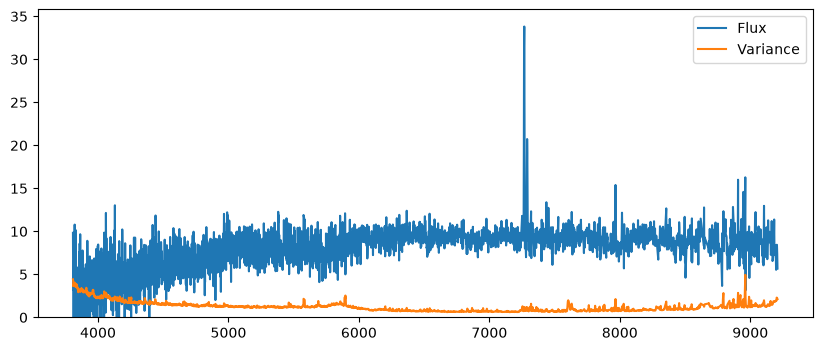

In [35]:
from astropy.io import fits
import matplotlib.pyplot as plt

f = fits.open('spec-0279-51608-0017.fits')
wave = 10**f[1].data['loglam']
mask = f[1].data['and_mask'].astype(bool) # mask
flux = f[1].data['flux']
ivar = f[1].data['ivar'] # inverse variance
zred = f[2].data['Z'] # redshift 

plt.figure(figsize=(10,4))
plt.plot(wave[~mask], flux[~mask], label='Flux')
plt.plot(wave[~mask], ivar[~mask]**-0.5, label='Variance')
plt.legend(loc='upper right')
plt.ylim(0, None)

print(f'galaxy redshift = {zred}')

In [36]:
from provabgs import infer as Infer
from provabgs import models as Models

In [37]:
# stellar population synthesis model
model = Models.NMF(burst=True, emulator=True)

input parameters : logmstar, beta1_sfh, beta2_sfh, beta3_sfh, beta4_sfh, fburst, tburst, gamma1_zh, gamma2_zh, dust1, dust2, dust_index


In [41]:
# default prior
prior = Infer.load_priors([
    Infer.UniformPrior(7., 12.5, label='sed'),
    Infer.FlatDirichletPrior(4, label='sed'),   # flat dirichilet priors
    Infer.UniformPrior(0., 1., label='sed'), # burst fraction
    Infer.UniformPrior(1e-2, 13.27, label='sed'), # tburst
    Infer.LogUniformPrior(4.5e-5, 1.5e-2, label='sed'), # log uniform priors on ZH coeff
    Infer.LogUniformPrior(4.5e-5, 1.5e-2, label='sed'), # log uniform priors on ZH coeff
    Infer.UniformPrior(0., 3., label='sed'),        # uniform priors on dust1
    Infer.UniformPrior(0., 3., label='sed'),        # uniform priors on dust2
    Infer.UniformPrior(-2., 1., label='sed')    # uniform priors on dust_index
])
print('draw sample from the prior in the transformed space')
print(prior.sample())

draw sample from the prior in the transformed space
[ 1.14769115e+01  6.11020803e-01  8.83372354e-01  1.45010772e-01
  6.30548055e-01  5.40845664e+00  2.97173555e-04  4.35038385e-03
  4.22601746e-01  1.47656815e+00 -8.42344335e-02]


**(a)** Update the example implementation below to include the masking. 
Then, find the MLE using optimization and initialize 32 walkers in a small ball around it. 

In [39]:
def log_prior(thetat): 
    return prior.lnPrior(thetat)

def log_likelihood(thetat):
    # example implementation of the log likelihood in the transformed space
    _, m_flux = model.sed(prior.transform(thetat), zred=zred, wave=wave)
    dflux = (m_flux - flux)**2 
    return -0.5 * np.sum(dflux * ivar)

**(b)** Run `EnsembleSampler` for at least 5000 steps. 
Investigate burnin using the walker traces and identify an appropriate burn-in to discard.
Compute the autocorrelation time with `sampler.get_autocorr_time` and use it to report the effective number of independent
samples in your flattened, burn-in-discarded chain.

**(c)** Make a corner plot of the posterior using `corner.corner` and report the marginalized 1D posteriors on `logmstar` with 68\% confidence intervals 